### Imports

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Dataframe loading and understanding

In [2]:
df = pd.read_csv("/kaggle/input/datasets/jeevannagaraj/indian-liver-patient-dataset/Indian Liver Patient Dataset (ILPD).csv")

In [3]:
df.head()

,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [4]:
df.shape

(583, 11)

In [5]:
df.isna().sum()

age                 0
gender              0
tot_bilirubin       0
direct_bilirubin    0
tot_proteins        0
albumin             0
ag_ratio            0
sgpt                0
sgot                0
alkphos             4
is_patient          0
dtype: int64

Only one **feature alkphos** is having missing values with a count of **"4"** values so we could easily drop it 

### Renamed the fetures for easy understanding

In [6]:
df.rename(columns = {"alkphos" : "alkaline_phosphate_enzyme", "sgpt" : "Serum_Glutamic_Pyruvic_Transaminase", "sgot" : "Serum_Glutamic_Oxaloacetic_Transaminase", "ag_ratio" : "Albumin/Globulin Ratio"} ,inplace = True)
df.columns.tolist()

['age',
 'gender',
 'tot_bilirubin',
 'direct_bilirubin',
 'tot_proteins',
 'albumin',
 'Albumin/Globulin Ratio',
 'Serum_Glutamic_Pyruvic_Transaminase',
 'Serum_Glutamic_Oxaloacetic_Transaminase',
 'alkaline_phosphate_enzyme',
 'is_patient']

In [7]:
df.dropna(inplace = True)

In [8]:
df.gender.value_counts()

gender
Male      439
Female    140
Name: count, dtype: int64

The dataset has a domination of male as **439** of **579** entries amd the rest **140** entries are females.

In [9]:
print(f"Range of Age : {df.age.min()} to {df.age.max()}")

Range of Age : 4 to 90


### Data Statistics and Visualization

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 579 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   age                                      579 non-null    int64  
 1   gender                                   579 non-null    object 
 2   tot_bilirubin                            579 non-null    float64
 3   direct_bilirubin                         579 non-null    float64
 4   tot_proteins                             579 non-null    int64  
 5   albumin                                  579 non-null    int64  
 6   Albumin/Globulin Ratio                   579 non-null    int64  
 7   Serum_Glutamic_Pyruvic_Transaminase      579 non-null    float64
 8   Serum_Glutamic_Oxaloacetic_Transaminase  579 non-null    float64
 9   alkaline_phosphate_enzyme                579 non-null    float64
 10  is_patient                               579 non-null  

In [11]:
df.describe()

,age,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,Albumin/Globulin Ratio,Serum_Glutamic_Pyruvic_Transaminase,Serum_Glutamic_Oxaloacetic_Transaminase,alkaline_phosphate_enzyme,is_patient
count,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000
mean,44.782383,3.315371,1.494128,291.366149,81.126079,110.414508,6.481693,3.138515,0.947064,1.284974
std,16.221786,6.227716,2.816499,243.561863,183.182845,289.850034,1.084641,0.794435,0.319592,0.451792
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,61.000000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


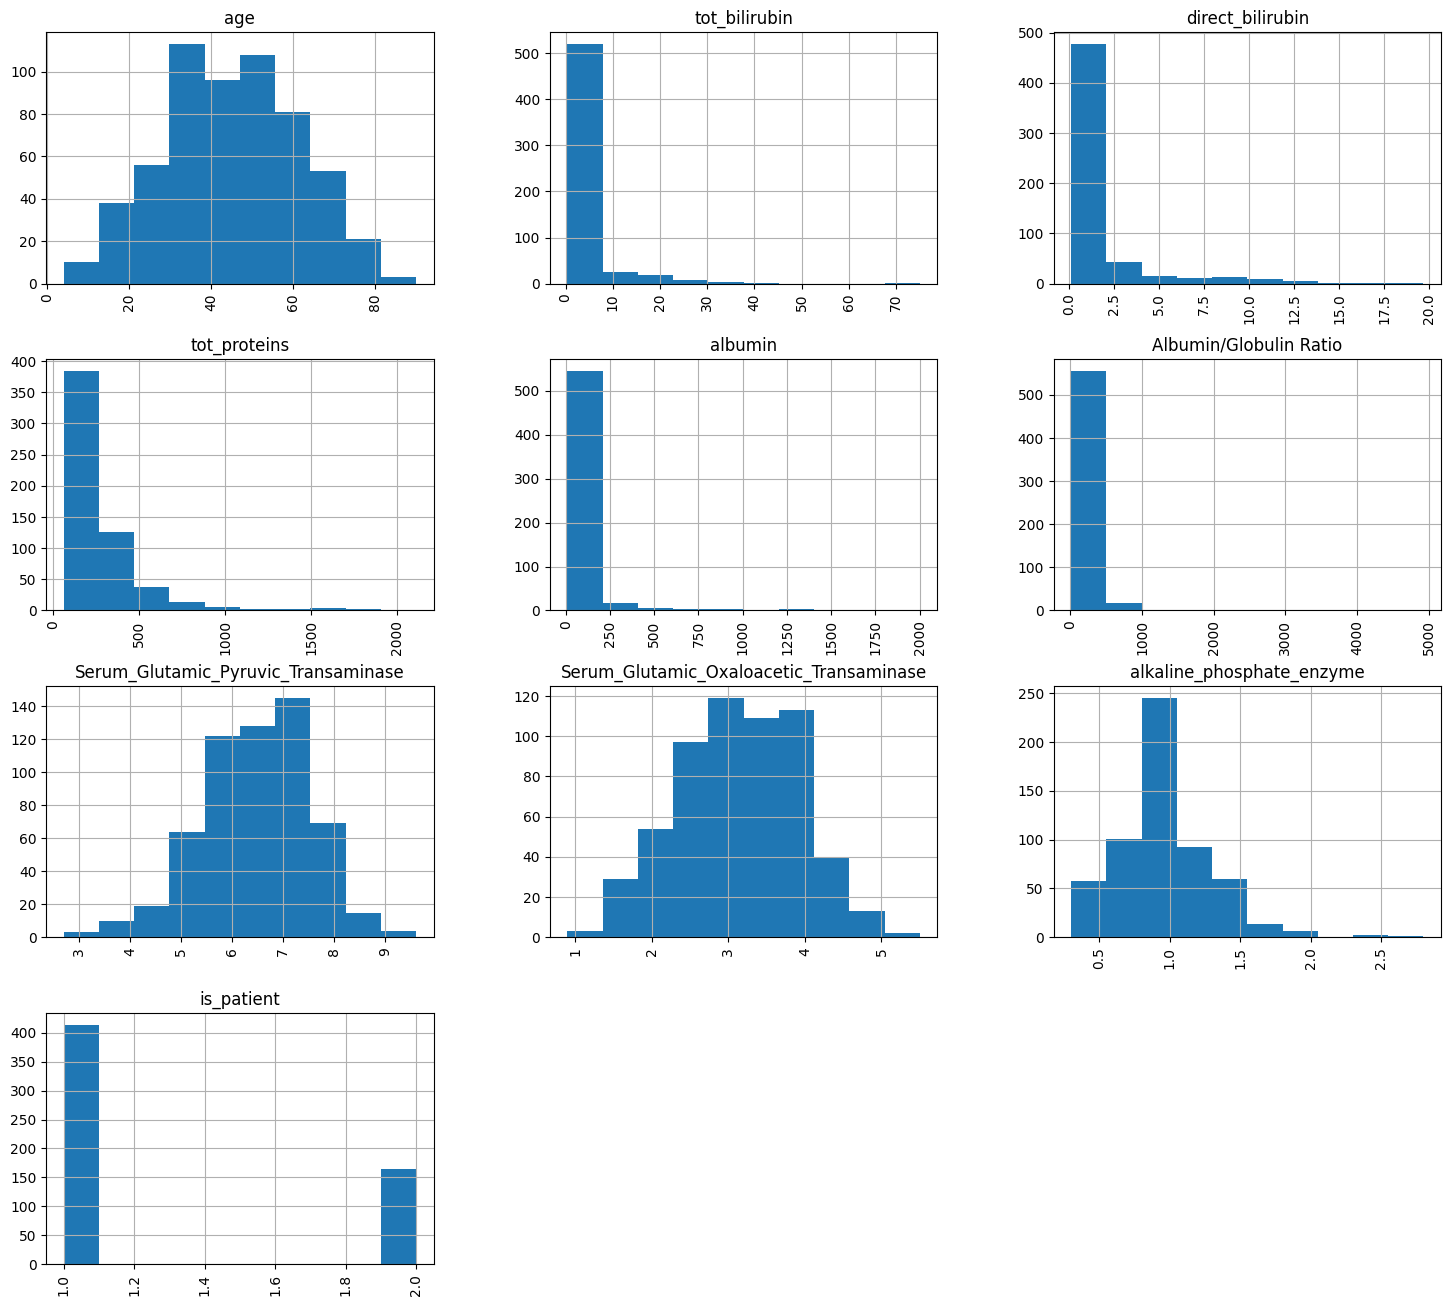

In [12]:
df.hist(xrot=90, figsize=(18, 16));

In [13]:
df.count()

age                                        579
gender                                     579
tot_bilirubin                              579
direct_bilirubin                           579
tot_proteins                               579
albumin                                    579
Albumin/Globulin Ratio                     579
Serum_Glutamic_Pyruvic_Transaminase        579
Serum_Glutamic_Oxaloacetic_Transaminase    579
alkaline_phosphate_enzyme                  579
is_patient                                 579
dtype: int64

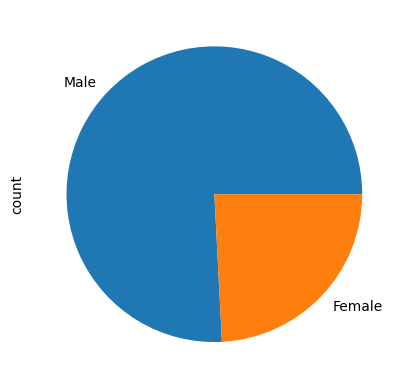

In [14]:
df['gender'].value_counts().plot.pie();

<Axes: xlabel='gender', ylabel='count'>

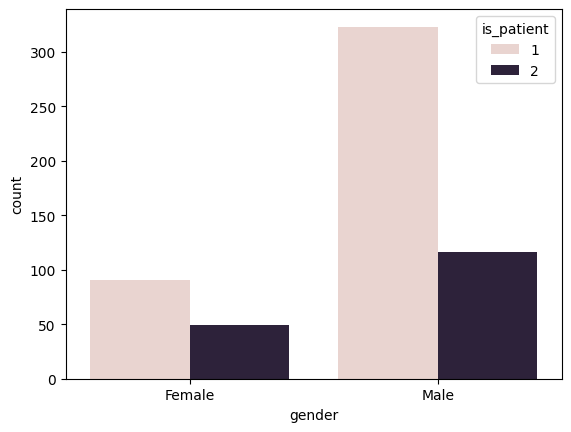

In [15]:
sns.countplot(data=df, x='gender', hue='is_patient')

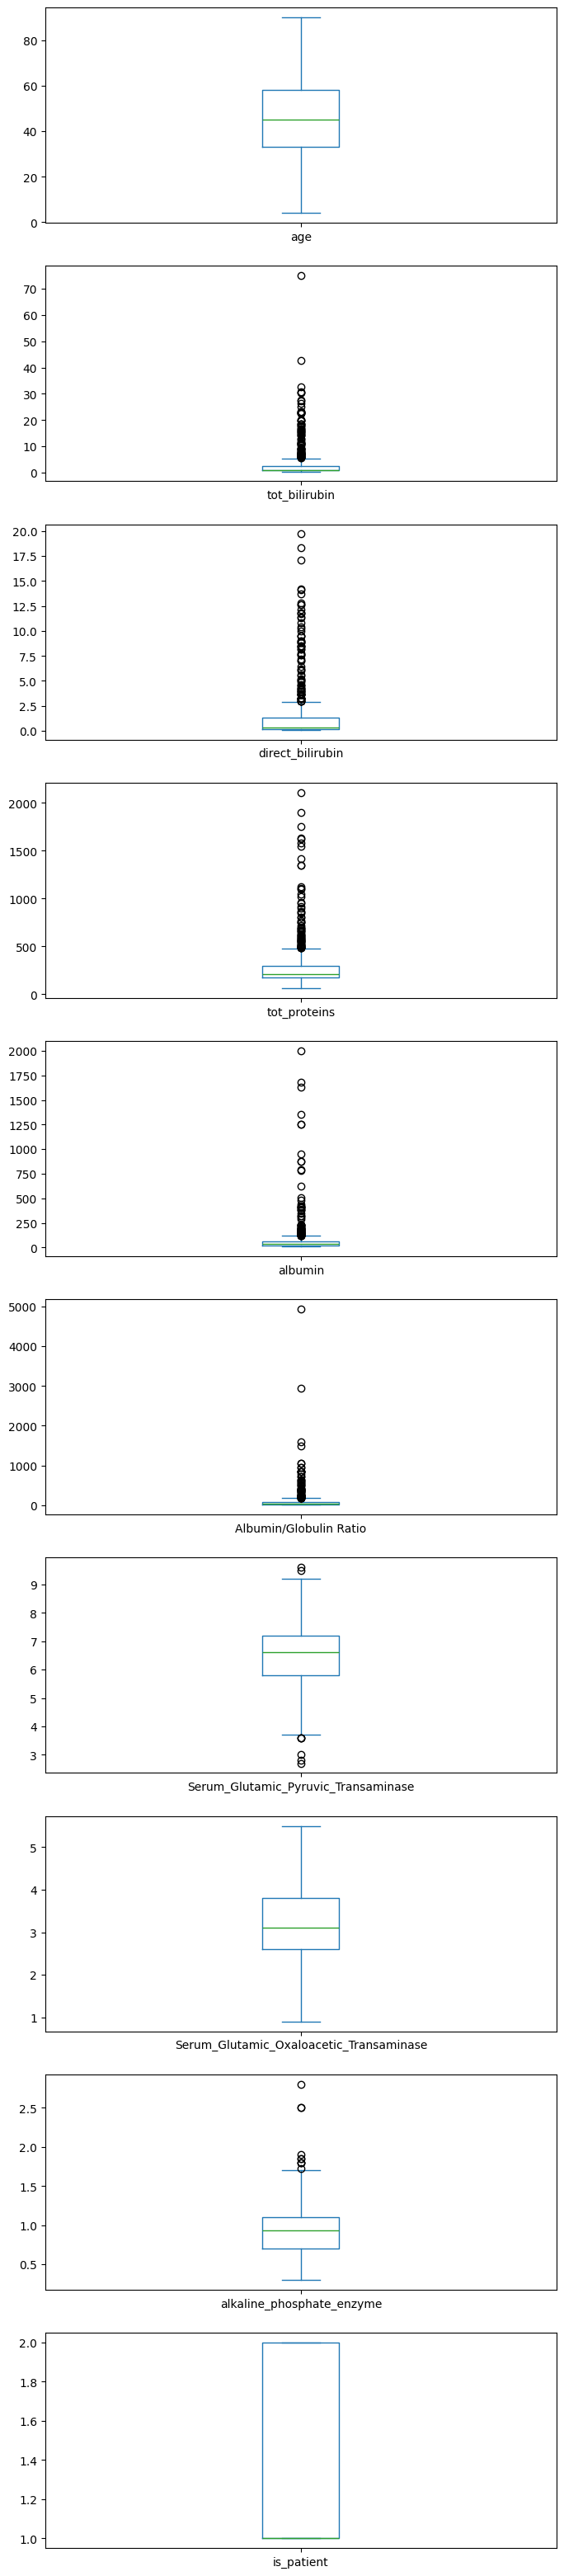

In [16]:
numeric_df = df.select_dtypes(include=['int', 'float'])
num_of_features = len(numeric_df.columns)
numeric_df.plot(
    kind='box', 
    figsize=(8,4 * num_of_features), 
    subplots=True,   
    sharey=False,
    layout=(num_of_features, 1)     
);

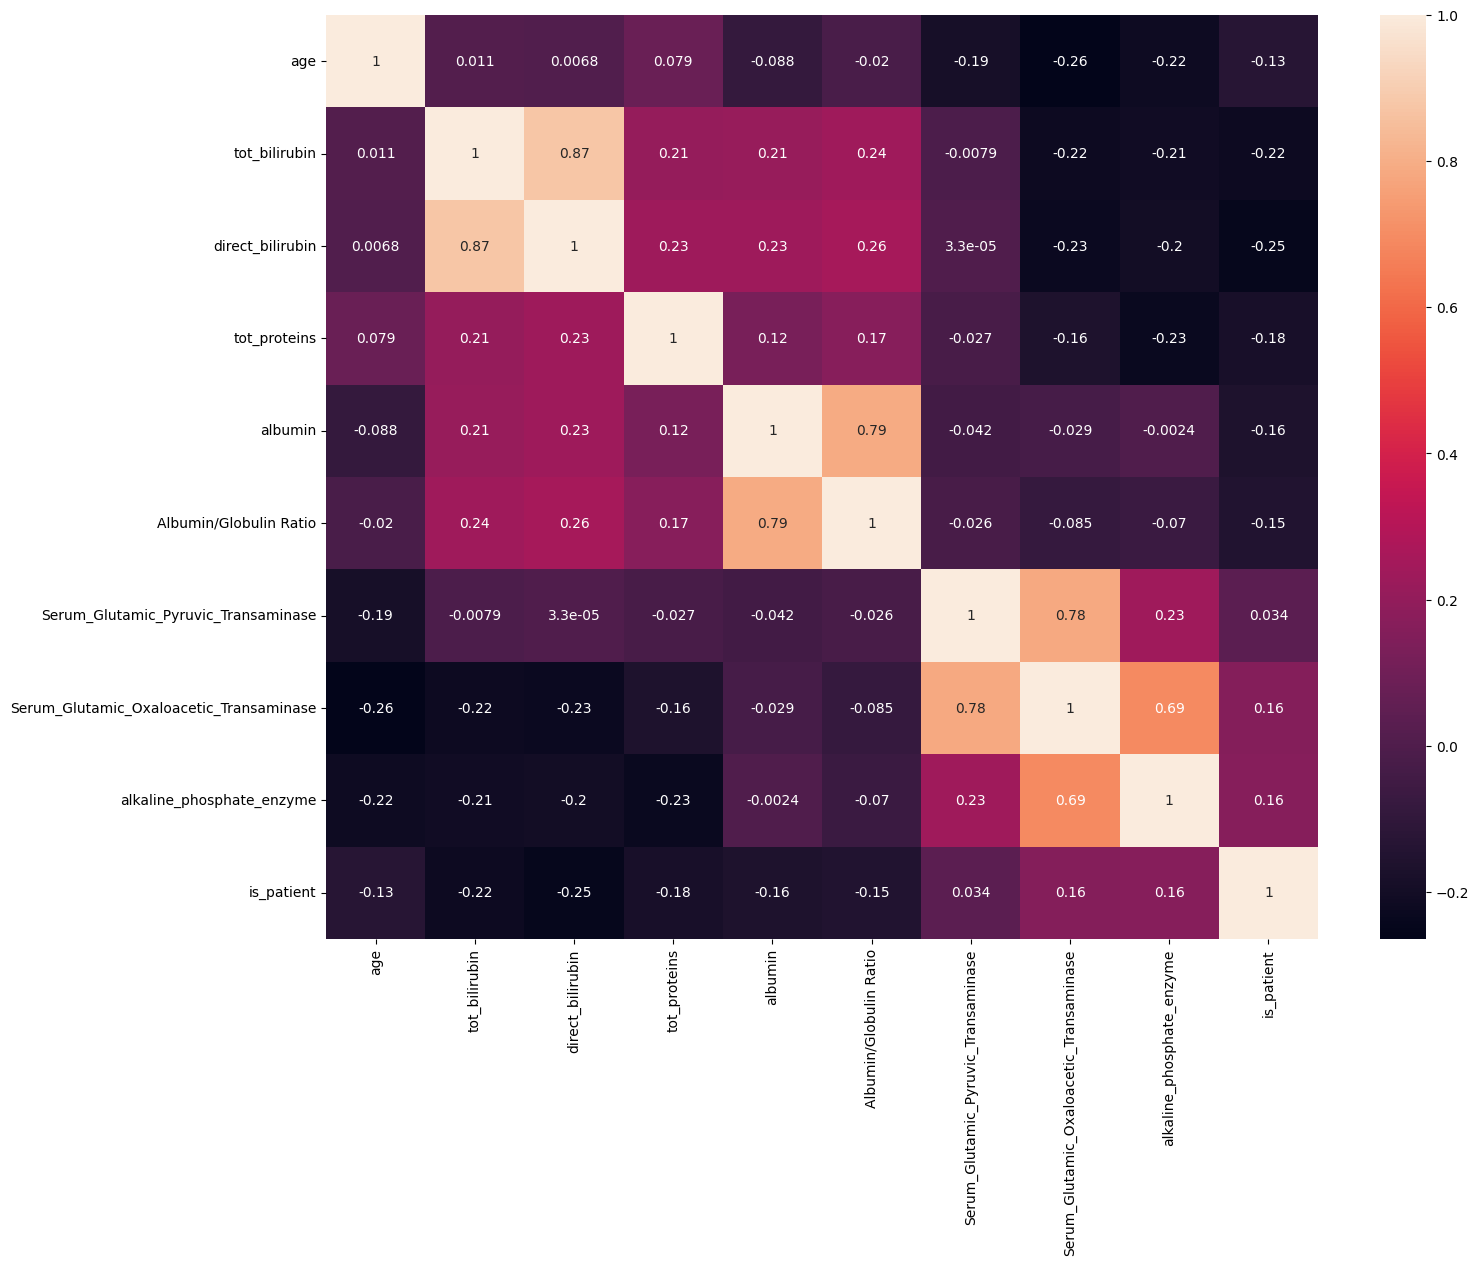

In [17]:
plt.figure(figsize = (16,12))
sns.heatmap(df.corr(numeric_only=True),annot = True);

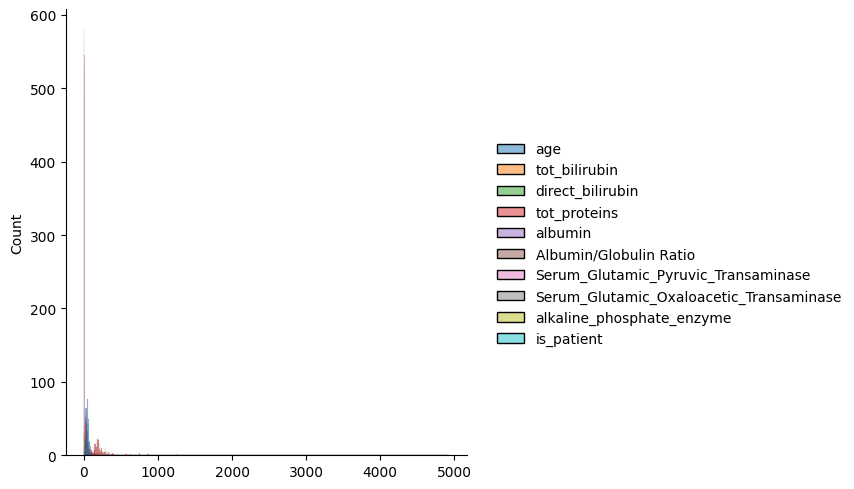

In [18]:
sns.displot(data=df);

### Pipelining, Modeling and Evaluation

In [19]:
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [20]:
X = df.drop(columns=['is_patient'])
y = df['is_patient']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [22]:
numeric_transformer = Pipeline([('scaler', StandardScaler())])
categorical_transformer = Pipeline([('encoder', OneHotEncoder())])

In [23]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()),
    ('cat', categorical_transformer, X_train.select_dtypes(include=['object', 'category']).columns.tolist())
])

In [24]:
from sklearn.linear_model import LogisticRegression
custom_weights = {1: 1.0, 2: 2.0}
pipeline = make_pipeline(preprocessor, LogisticRegression(class_weight=custom_weights, random_state=42))
pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tot_bilirubin',
                                                   'direct_bilirubin',
                                                   'tot_proteins', 'albumin',
                                                   'Albumin/Globulin Ratio',
                                                   'Serum_Glutamic_Pyruvic_Transaminase',
                                                   'Serum_Glutamic_Oxaloacetic_Transaminase',
                                                   'alkaline_phosphate_enzyme']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder())]),
                                                  ['gender'])])),
                ('logisticregression',
                 LogisticRegression(class_weight={1: 1.0, 2: 2.0},
                                    random_state=42))])

In [25]:
from sklearn.metrics import classification_report,confusion_matrix
y_pred = pipeline.predict(X_test)

In [26]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.round(4)

In [27]:
print(df_report.T)

                 1        2  accuracy  macro avg  weighted avg
precision   0.8462   0.3906    0.5948     0.6184        0.7166
recall      0.5301   0.7576    0.5948     0.6438        0.5948
f1-score    0.6519   0.5155    0.5948     0.5837        0.6131
support    83.0000  33.0000    0.5948   116.0000      116.0000


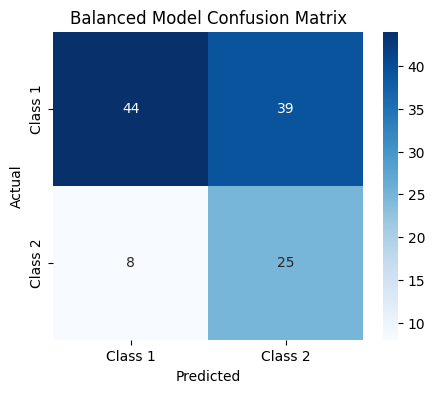

In [28]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 1', 'Class 2'], 
            yticklabels=['Class 1', 'Class 2'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Balanced Model Confusion Matrix')
plt.show()

In [29]:
tn, fp, fn, tp = cm.ravel()
print(tn, fp, fn, tp)

44 39 8 25


In [30]:
from sklearn.ensemble import RandomForestClassifier
rf_pipeline = make_pipeline(
    preprocessor, 
    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tot_bilirubin',
                                                   'direct_bilirubin',
                                                   'tot_proteins', 'albumin',
                                                   'Albumin/Globulin Ratio',
                                                   'Serum_Glutamic_Pyruvic_Transaminase',
                                                   'Serum_Glutamic_Oxaloacetic_Transaminase',
                                                   'alkaline_phosphate_enzyme']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder())]),
                                                  ['gender'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [31]:
y_pred_rf = rf_pipeline.predict(X_test)

In [32]:
pd.DataFrame(classification_report(y_test, y_pred_rf, output_dict=True)).transpose().round(4)

,precision,recall,f1-score,support
1,0.7789,0.8916,0.8315,83.0000
2,0.5714,0.3636,0.4444,33.0000
accuracy,0.7414,0.7414,0.7414,0.7414
macro avg,0.6752,0.6276,0.6380,116.0000
weighted avg,0.7199,0.7414,0.7214,116.0000


In [33]:
confusion_matrix(y_test, y_pred_rf)

array([[74,  9],
       [21, 12]])

### Model refinements

In [34]:
# Lowering the thresold
rf_probs = rf_pipeline.predict_proba(X_test)[:, 1] 
custom_threshold = 0.35 

In [35]:
y_pred_custom = np.where(rf_probs >= custom_threshold, 2, 1) 

In [36]:
pd.DataFrame(classification_report(y_test, y_pred_custom,output_dict=True)).transpose().round(4)

,precision,recall,f1-score,support
1,0.8387,0.6265,0.7172,83.0000
2,0.4259,0.6970,0.5287,33.0000
accuracy,0.6466,0.6466,0.6466,0.6466
macro avg,0.6323,0.6617,0.6230,116.0000
weighted avg,0.7213,0.6466,0.6636,116.0000


In [37]:
confusion_matrix(y_test, y_pred_custom)

array([[52, 31],
       [10, 23]])

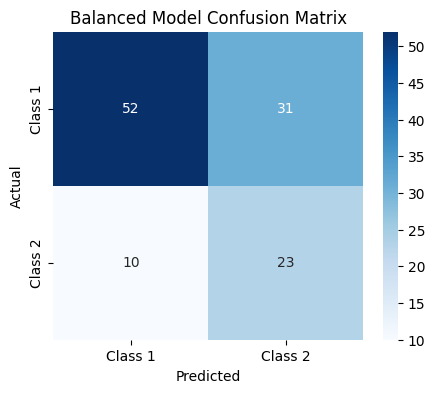

In [38]:
cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 1', 'Class 2'], 
            yticklabels=['Class 1', 'Class 2'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Balanced Model Confusion Matrix')
plt.show()